### Построение baseline сверточной модели
- Цель: построить очень простую сверточную можель классификации, используя Torch

In [1]:
import math
import time
import random
import os
from typing import Dict, List

import torch
import torchvision
from torch.utils.data import DataLoader, Subset, random_split
import torch.nn as nn

from torchvision.datasets import ImageFolder
from torchvision import transforms

from torchmetrics.classification import MulticlassRecall, MulticlassF1Score, MulticlassPrecision, MulticlassAccuracy

from sklearn.model_selection import train_test_split

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = "../data/trashnet"
ARTIFACTS_DIR ="../artifacts"
LOG_FILE = "runs.csv"
BATCH_SIZE = 128
EPOCHS = 12

# -----------------------
# Воспроизводимость
# -----------------------
RANDOM_STATE = 42
def set_seed(seed: int = RANDOM_STATE) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)


# -----------------------
# Устройство
# -----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print('torch:', torch.__version__)
print("torchvision:", torchvision.__version__)

Device: cpu
torch: 2.12.0+cpu
torchvision: 0.27.0+cpu


In [2]:
IMG_SIZE = 96
TRASHNET_MEAN = (0.673, 0.640, 0.605)
TRASHNET_STD = (0.209, 0.210, 0.232)
tf_train = transforms.Compose([
    transforms.Resize(IMG_SIZE+14),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.4,             # Probability of applying the transform
        scale=(0.02, 0.20),# Range of proportion of erased area against the input image
        ratio=(0.3, 3.3),  # Range of aspect ratio of erased area
        value=0,           # Value to fill erased pixels (0 for black, or a tuple for RGB)
        inplace=False
    ),
    transforms.Normalize(TRASHNET_MEAN,TRASHNET_STD),
])
tf_test = transforms.Compose([
    transforms.Resize(IMG_SIZE+14),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(TRASHNET_MEAN,TRASHNET_STD)
])

train_full = ImageFolder(DATA_DIR,transform=tf_train)
test_full = ImageFolder(DATA_DIR,transform=tf_test)

targets = np.array(train_full.targets)

train_idx, temp_idx = train_test_split(
    range(len(train_full.targets)),
    test_size=0.2,
    stratify=targets,
    random_state=RANDOM_STATE,
    shuffle=True
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,              
    stratify=targets[temp_idx], 
    random_state=RANDOM_STATE,
    shuffle=True
)

train_dataset = Subset(train_full, train_idx)
val_dataset   = Subset(test_full, val_idx)
test_dataset  = Subset(test_full, test_idx)


In [3]:
# Создаем загрузчики данных

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print("="*20, "SANITY CHECK","="*20)

print("Данные по train")
batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)


print("\nДанные по test")
batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

==================== SANITY CHECK ====================
Данные по train
x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64

Данные по test
x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64


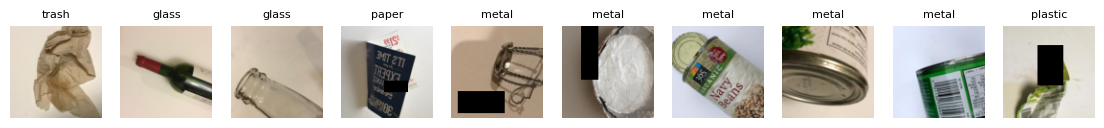

In [4]:
class_names = train_full.classes

def denorm_STL(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(TRASHNET_MEAN).view(3, 1, 1)
    std = torch.tensor(TRASHNET_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_STL(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [5]:
INPUT_DIM = 96 * 96 * 3
NUM_CLASSES = 6

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 96x96 -> 96x96
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 96x96 -> 48x48

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 48x48 -> 48x48
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 48x48 -> 24x24

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 24x24 -> 24x24
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 24x24 -> 12x12

            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 12x12 -> 12x12
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 12x12 -> 6x6
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=6, bias=True)
  )
)
Trainable params: 5110598


In [6]:
# Sanity-check
with torch.no_grad():
    x0 = torch.randn(2, 3, 96, 96).to(DEVICE)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 96, 96]) Output logits: torch.Size([2, 6])


In [7]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


@torch.no_grad()
def metrics_on_loader(model, loader):

    model.eval()
    model.to(DEVICE)


    recall = MulticlassRecall(num_classes=NUM_CLASSES,average="macro").to(DEVICE)
    f1score = MulticlassF1Score(num_classes=NUM_CLASSES,average="macro").to(DEVICE)
    precision = MulticlassPrecision(num_classes=NUM_CLASSES,average="macro").to(DEVICE)
    accuracy = MulticlassAccuracy(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

    for x, labels in loader:
        x, labels = x.to(DEVICE), labels.to(DEVICE)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        recall.update(preds,labels)
        f1score.update(preds,labels)
        precision.update(preds,labels)
        accuracy.update(preds,labels)

    metrics = {
        'accuracy': accuracy.compute().item(),
        'recall_macro': recall.compute().item(),
        'precision_macro': precision.compute().item(),
        'f1_macro': f1score.compute().item(),
    }
    
    return metrics


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = EPOCHS, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        dt = time.time() - t0

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )


        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        
        

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]],save="", title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    if save:
        plt.tight_layout()
        plt.savefig(ARTIFACTS_DIR+"/figures/"+save+"_1.png")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    if save:
        plt.tight_layout()
        plt.savefig(ARTIFACTS_DIR+"/figures/"+save+"_2.png")
    plt.show()


Experiment CNN Base | lr=1e-3 weight_decay=0.0 epochs=12
Trainable params: 5110598
Epoch 01/12 | train loss 1.7233, acc 0.236 | val loss 1.5838, acc 0.344 | 15.5s
Epoch 02/12 | train loss 1.4693, acc 0.401 | val loss 1.3686, acc 0.447 | 14.5s
Epoch 03/12 | train loss 1.3369, acc 0.459 | val loss 1.2411, acc 0.542 | 13.9s
Epoch 04/12 | train loss 1.1780, acc 0.540 | val loss 1.1164, acc 0.605 | 14.8s
Epoch 05/12 | train loss 1.0841, acc 0.583 | val loss 1.0928, acc 0.589 | 14.0s
Epoch 06/12 | train loss 1.0339, acc 0.602 | val loss 1.1122, acc 0.605 | 17.6s
Epoch 07/12 | train loss 0.9698, acc 0.644 | val loss 1.0380, acc 0.664 | 15.2s
Epoch 08/12 | train loss 0.8782, acc 0.675 | val loss 1.0043, acc 0.660 | 13.9s
Epoch 09/12 | train loss 0.8118, acc 0.695 | val loss 1.0208, acc 0.680 | 15.8s
Epoch 10/12 | train loss 0.7313, acc 0.731 | val loss 0.8954, acc 0.696 | 15.3s
Epoch 11/12 | train loss 0.6848, acc 0.757 | val loss 0.8559, acc 0.672 | 15.1s
Epoch 12/12 | train loss 0.6888, acc

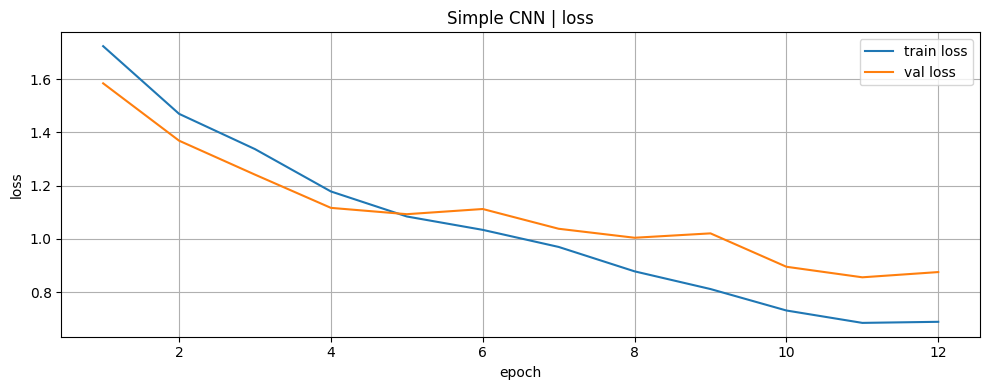

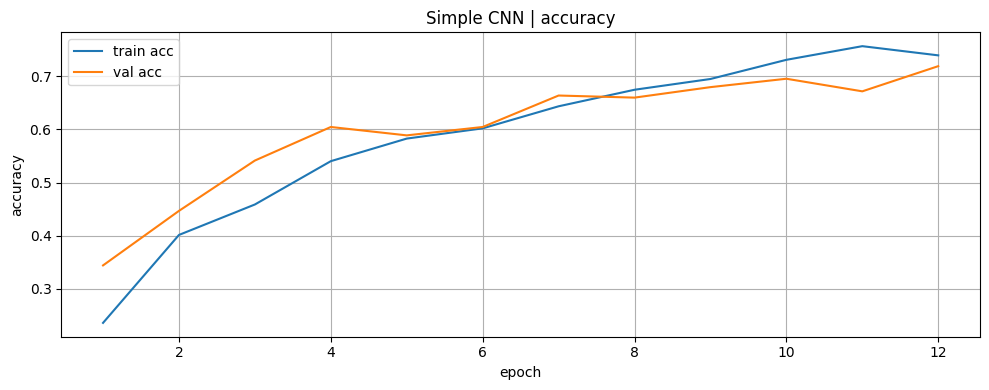

In [8]:
set_seed()
criterion = nn.CrossEntropyLoss()
simple_cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
base_cnn_optimizer = torch.optim.Adam(simple_cnn.parameters(), lr=1e-3, weight_decay=0.0)

print("\n" + "=" * 80)
print(f"Experiment CNN Base | lr=1e-3 weight_decay=0.0 epochs={EPOCHS}")
print("Trainable params:", count_params(simple_cnn))

simple_CNN_hist = fit(simple_cnn, train_loader, val_loader, base_cnn_optimizer, criterion, epochs=EPOCHS, verbose=True)
best_val_acc = float(np.nanmax(simple_CNN_hist["val_acc"])) if len(simple_CNN_hist["val_acc"]) else float("nan")
print(f"Лучшая acc на val: {best_val_acc}")
plot_history(simple_CNN_hist, title="Simple CNN", save="Simple_CNN_train")


In [9]:
# Сохраняем результаты

Simple_CNN_data = {'experiment_id': 'S1',
           'task': 'classification',
           'dataset': 'TrashNet',
           'seed': RANDOM_STATE,
           'model_summary': f'base CNN; Trainable params: {count_params(simple_cnn)}',
            'optimizer': 'Adam',
            'lr': 1e-3,
            'epochs_trained': EPOCHS,
            'best_val_accuracy': best_val_acc,
            'test_accuracy': None,
            'precision': None,
            'recall': None,
            'notes':'Baseline model', 
        }   
file_exists = os.path.exists(ARTIFACTS_DIR+"/"+LOG_FILE) and os.path.getsize(ARTIFACTS_DIR+"/"+LOG_FILE) > 0
pd.DataFrame([Simple_CNN_data]).to_csv(
            ARTIFACTS_DIR+"/"+LOG_FILE, 
            header=not file_exists, 
            mode='a', 
            index=False
        )